
For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 
$$
M_{\rm irr} =
 M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
$$
For convenience, let us define 

$$f(\chi) = \frac{M_{\rm irr}}{M}= \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.


7.  Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result: 

\begin{equation}
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
\end{equation}

8.  Compute the pdfs of $M_{\rm irr}$ from its mathematical definition (pen and paper!). Verify this result:

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f
$$

The this expression is only semi-analytic; that integral should then be solved numerically.

*Point 7 and point 8 are **not examinable**; those are interesting calculations but you can just assume those expressions and move on with point 9 if you want.*

*Hint (for point 8)*: You want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables. 

9. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.


# import

In [108]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# code

In [109]:
#set mu mass = 1, sigma = 0.02
#masses normally distributed
sigma = 0.2
mu = 1
size = 5000
mass = np.random.normal( loc = mu, scale = sigma, size = size)
spin = np.random.uniform(low = 0, high = 1, size = size)

In [110]:
def scott(data, sigma):
    return 3.5 * sigma / len(data)**(1/3)

def freedmanDiaconis(data, sigma):
    return 2.7 * sigma / (len(data))**(1/3)

def M_irr(m, chi):
    return m * np.sqrt((1 + np.sqrt(1 - chi **2)) / 2)

Text(0.5, 0, 'Mass [mu]')

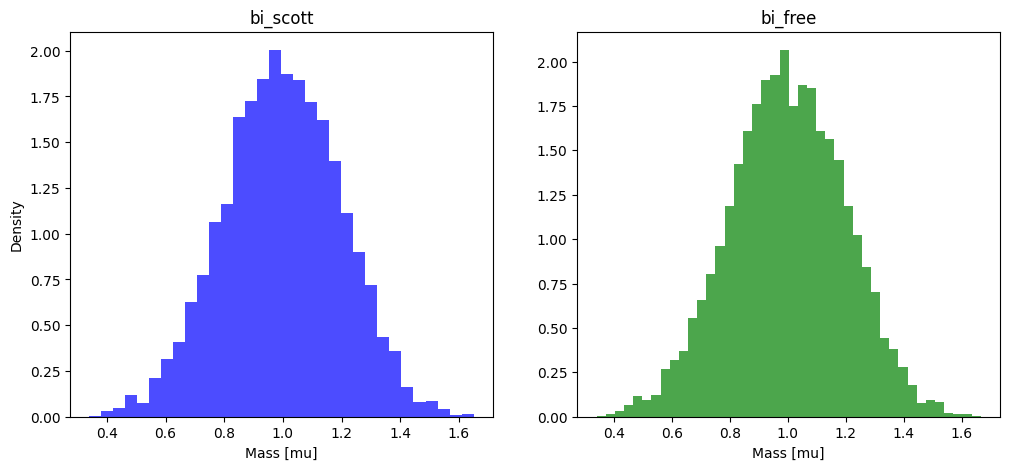

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bin_scott = np.arange(mass.min(), mass.max(), scott(mass, sigma))
bin_fd = np.arange(mass.min(), mass.max(), freedmanDiaconis(mass, sigma))

axes[0].hist(mass, bins= bin_scott, density=True, alpha=0.7, color = 'blue')
axes[0].set_title('bi_scott')
axes[0].set_xlabel('Mass [mu]')
axes[0].set_ylabel('Density')

axes[1].hist(mass, bins=bin_fd, density=True, alpha=0.7, color='green')
axes[1].set_title('bi_free')
axes[1].set_xlabel('Mass [mu]')


In [112]:
m_irr = M_irr(mass, spin)

Text(0.5, 1.0, 'bi_free')

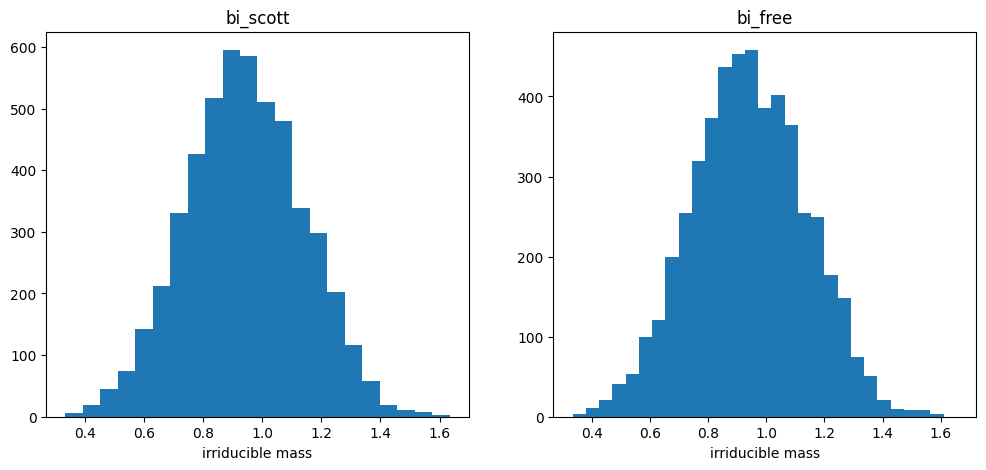

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bin_scott = np.arange(m_irr.min(), m_irr.max(), scott(m_irr, 1/np.sqrt(12)))
bin_fd    = np.arange(m_irr.min(), m_irr.max(), freedmanDiaconis(m_irr, 1/np.sqrt(12)))

axes[0].hist(m_irr, bins = bin_scott)
axes[0].set_xlabel('irriducible mass')
axes[0].set_title('bi_scott')

axes[1].hist(m_irr, bins = bin_fd)
axes[1].set_xlabel('irriducible mass')
axes[1].set_title('bi_free')

In [114]:
# now i want to use KDE...

def kde_sklearn(data, bandwidth = 1.0, kernel="linear", x = []):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

x_grid = np.linspace(m_irr.min(), m_irr.max(), size )

#riduco sample size, ci mette troppo tempo
bandwidth = 0.02
tophat = kde_sklearn(m_irr, bandwidth = bandwidth, kernel = "tophat", x = x_grid[:])


In [115]:
gaussian = kde_sklearn(m_irr, bandwidth = bandwidth, kernel = "gaussian", x = x_grid[:])
# too much expensive in terms of time, maybe because the gaussian kernal as "infinite" tails., go on with other kernel, i was doing 1e5 size

In [116]:
epanechnikov = kde_sklearn(m_irr, bandwidth = bandwidth, kernel = "epanechnikov", x = x_grid[:])

In [117]:
linear = kde_sklearn(m_irr, bandwidth = bandwidth, kernel = "linear", x = x_grid[:])


\begin{equation}
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
\end{equation}

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f
$$

In [128]:
from scipy.integrate import quad

def pdf_f(f):
    return 2 * (2 * f**2 - 1) / np.sqrt(1 - f **2)

def f(chi):
    return np.sqrt((1 + np.sqrt (1 - chi**2)) / 2 )

def M_irr(m, chi):
    return m * f(chi)

def integrand(f_val, mirr, mu, sigma):
    return np.exp(- (mirr / f_val - mu)**2 / (2 * sigma**2)) * pdf_f(f_val) / f_val

def pdf_mirr(mirr, mu, sigma):
    # support scalar or array input for mirr
    mirr_arr = np.atleast_1d(mirr)
    results = []
    for val in mirr_arr:
        integral, _ = quad(integrand, 1/np.sqrt(2), 1, args=(val, mu, sigma))
        results.append(np.sqrt(2 / np.pi) / sigma * integral)
    results = np.array(results)
    return results if mirr_arr.shape[0] > 1 else results[0]

Text(0.5, 1.0, 'linear')

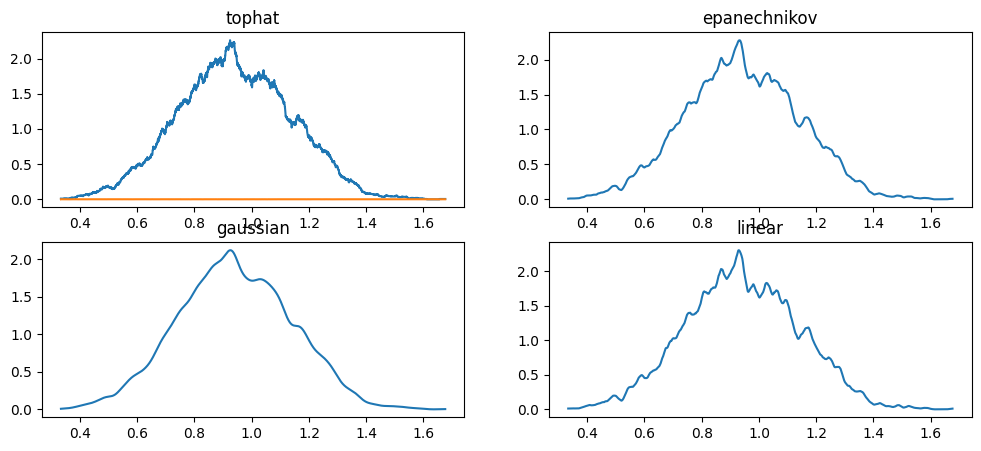

In [129]:

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
axes[0, 0].plot(x_grid, tophat, )
# axes[0, 0].plot(x_grid, pdf_f(f(spin)), color = 'orange')
axes[0, 0].plot(x_grid, pdf_mirr(m_irr, mu, sigma))
axes[0, 0].set_title('tophat')
axes[0, 1].plot(x_grid, epanechnikov)
axes[0, 1].set_title('epanechnikov')
axes[1, 0].plot(x_grid, gaussian)
axes[1, 0].set_title('gaussian')
axes[1, 1].plot(x_grid, linear)
axes[1, 1].set_title('linear')

/tmp/ipykernel_6479/3528031283.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, theta, axis=1)


Text(0.5, 1.0, 'Semi-analytic PDF vs KDE')

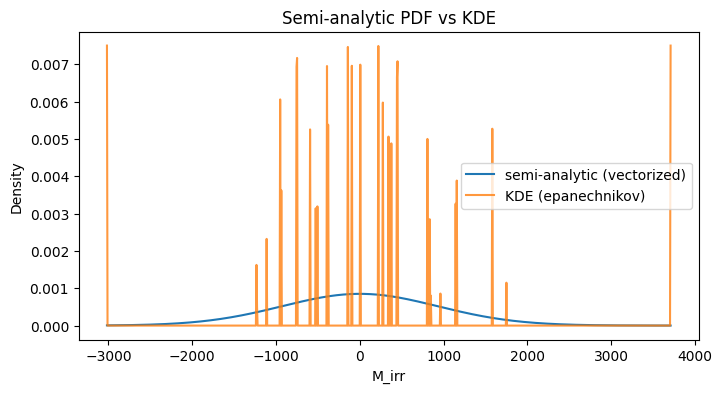

In [130]:
# Vectorized semi-analytic PDF using f = cos(theta) substitution to remove the sqrt singularity
theta = np.linspace(0, np.pi/4, 400)  # integration variable: 0..pi/4 corresponds to f in [1/sqrt(2), 1]
cos_t = np.cos(theta)
pref = 2 * (2 * cos_t**2 - 1) / cos_t  # 2*(2 cos^2 -1)/cos(t)

def pdf_mirr_vec(mirr_arr, mu, sigma, theta=theta, cos_t=cos_t, pref=pref):
    mirr = np.atleast_1d(mirr_arr)
    # ratio shape: (N, T)
    ratio = mirr[:, None] / cos_t[None, :]
    expo = np.exp(- (ratio - mu)**2 / (2 * sigma**2))
    integrand = expo * pref[None, :]
    integral = np.trapz(integrand, theta, axis=1)
    out = np.sqrt(2 / np.pi) / sigma * integral
    return out if out.shape[0] > 1 else out[0]

# Evaluate the semi-analytic pdf on a modest grid for speed
x_eval = np.linspace(m_irr.min(), m_irr.max(), 1000)
pdf_semi = pdf_mirr_vec(x_eval, mu, sigma)

# Build a KDE on the sample and evaluate on the same grid (use a compact kernel for speed)
from sklearn.neighbors import KernelDensity
kde = KernelDensity(bandwidth=bandwidth, kernel='epanechnikov')
kde.fit(m_irr[:, None])
log_pdf_kde = kde.score_samples(x_eval[:, None])
pdf_kde = np.exp(log_pdf_kde)

# Plot comparison
plt.figure(figsize=(8, 4))
plt.plot(x_eval, pdf_semi, label='semi-analytic (vectorized)')
plt.plot(x_eval, pdf_kde, label='KDE (epanechnikov)', alpha=0.8)
plt.xlabel('M_irr')
plt.ylabel('Density')
plt.legend()
plt.title('Semi-analytic PDF vs KDE')

they all have the same bandwidth I assigned casually, maybe too large for gaussian type

## 4

In [120]:


sigmas = np.logspace(-3, 3, 100)
ks_values = []
for sigma in sigmas:
    np.random.seed(100)
    mass = np.random.normal(loc = mu, scale = sigma, size = size)
    m_irr = M_irr(mass, spin)
    ks = st.ks_2samp(m_irr, f(spin))
    ks_values.append(ks)

In [121]:
# Extract and print important information from ks_values
ks_statistics = [ks.statistic for ks in ks_values]
ks_pvalues = [ks.pvalue for ks in ks_values]

print("KS Statistics:", ks_statistics)
print("KS P-values:", ks_pvalues)
# print("\nSigma values:", sigmas)
print("\nKS Statistic vs Sigma:")
for sigma_val, ks_stat in zip(sigmas, ks_statistics):
    print(f"  σ = {sigma_val:.2f}: KS = {ks_stat:.4f}")

KS Statistics: [np.float64(0.0356), np.float64(0.0388), np.float64(0.0426), np.float64(0.0444), np.float64(0.0464), np.float64(0.0498), np.float64(0.0548), np.float64(0.0604), np.float64(0.0642), np.float64(0.0686), np.float64(0.073), np.float64(0.079), np.float64(0.0854), np.float64(0.0922), np.float64(0.0984), np.float64(0.1054), np.float64(0.113), np.float64(0.1218), np.float64(0.1306), np.float64(0.1394), np.float64(0.1508), np.float64(0.1592), np.float64(0.17), np.float64(0.179), np.float64(0.1914), np.float64(0.202), np.float64(0.2124), np.float64(0.2268), np.float64(0.2436), np.float64(0.2592), np.float64(0.2728), np.float64(0.286), np.float64(0.2996), np.float64(0.3146), np.float64(0.3306), np.float64(0.3488), np.float64(0.3642), np.float64(0.3768), np.float64(0.3896), np.float64(0.4006), np.float64(0.4102), np.float64(0.4232), np.float64(0.4322), np.float64(0.4402), np.float64(0.447), np.float64(0.454), np.float64(0.46), np.float64(0.466), np.float64(0.4722), np.float64(0.4764

for small sigma: M is constant, so m_irr is almost sistributed as f ==> KS distance is smaller

for large sigma: M is no longer constant, m_irr != f ==> KS distance is larger

## 5

In [122]:
# 5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$.
#  Discuss the limits at large and small values of $\sigma$.

ks_values = []
for sigma in sigmas:
    np.random.seed(100)
    mass = np.random.normal(loc = mu, scale = sigma, size = size)
    m_irr = M_irr(mass, spin)
    ks = st.ks_2samp(m_irr, mass)
    ks_values.append(ks)

In [123]:
ks_statistics = [ks.statistic for ks in ks_values]
ks_pvalues = [ks.pvalue for ks in ks_values]

print("KS Statistics:", ks_statistics)
print("KS P-values:", ks_pvalues)
# print("\nSigma values:", sigmas)
print("\nKS Statistic vs Sigma:")
for sigma_val, ks_stat in zip(sigmas, ks_statistics):
    print(f"  σ = {sigma_val:.2f}: KS = {ks_stat:.4f}")

KS Statistics: [np.float64(0.8588), np.float64(0.851), np.float64(0.8394), np.float64(0.8298), np.float64(0.8172), np.float64(0.8042), np.float64(0.7908), np.float64(0.7774), np.float64(0.7626), np.float64(0.7494), np.float64(0.7352), np.float64(0.7212), np.float64(0.7062), np.float64(0.6892), np.float64(0.6724), np.float64(0.6526), np.float64(0.6298), np.float64(0.6088), np.float64(0.588), np.float64(0.5688), np.float64(0.5438), np.float64(0.5208), np.float64(0.4968), np.float64(0.4662), np.float64(0.438), np.float64(0.4112), np.float64(0.384), np.float64(0.358), np.float64(0.3328), np.float64(0.3068), np.float64(0.28), np.float64(0.2576), np.float64(0.2316), np.float64(0.208), np.float64(0.1848), np.float64(0.1658), np.float64(0.149), np.float64(0.134), np.float64(0.1174), np.float64(0.1056), np.float64(0.0942), np.float64(0.0848), np.float64(0.0748), np.float64(0.067), np.float64(0.06), np.float64(0.0542), np.float64(0.0488), np.float64(0.0444), np.float64(0.0394), np.float64(0.0364

for small sigma: M is constant, so m_irr is almost distributed as f not as M ==> KS distance is larger

for large sigma: M is no longer constant, m_irr is linear with sigma  ==> KS distance is smaller

point 6 non esiste

<!-- 7 easy (sqrt(1-chi) = y, dopo integro sqrt((1 - y) /2)) -->

